# EDA 5 - Yee & Dennett (2001-2011) vs Flow Cascade Typology with 2011 OD data

In [17]:
# ── imports ──────────────────────────────────────────
import sys
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from pyprojroot import here

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight'})

In [18]:
# ── paths ──────────────────────────────────────────
ROOT       = here()
sys.path.insert(0, str(ROOT))
DATA_DIR   = ROOT / 'data'
OUT_DIR    = ROOT / 'outputs'
GEO_PATH   = DATA_DIR / 'london_msoa_2011.geojson'
FIG_DIR    = OUT_DIR / 'comparison_figs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

YEE_LABELS = DATA_DIR / 'yee_LSOA_labels_forMapping.csv'
LOOKUP     = OUT_DIR / 'lsoa11_to_msoa11.csv'
EDA4       = OUT_DIR  / 'eda4_results_for_phase3_20260626.csv'

In [19]:
# ── theme ──────────────────────────────────────────
from map_utils import load_london_msoa, plot_london_categorical

# FLOW_TYP = 'Typ_A_11'                       # 2011 leg, London-only frame (matches Yee)
FLOW_TYP_A = 'Typ_A_11'
FLOW_TYP_C = 'Typ_C_11'

GENTRIFYING = {'GEN'}                        # widen to {'GEN','IUP'} for a broader definition


In [20]:
# ── Comparison helpers ────────────────────────────────────────────────────────

## measuring association or agreement between 2 categorical classifications
def cramers_v(x, y):
    """Bias-corrected Cramér's V (Bergsma 2013)."""
    tab = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tab, correction=False)[0]
    n = tab.values.sum(); r, k = tab.shape
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    denom = min(kc - 1, rc - 1)
    return np.sqrt(phi2 / denom) if denom > 0 else np.nan


def modal_aggregate(lsoa_df, class_col):
    g = lsoa_df.groupby('msoa11cd')
    modal = g[class_col].agg(lambda s: s.value_counts().index[0])
    conf = g[class_col].agg(lambda s: s.value_counts().iloc[0] / len(s))
    return modal.rename('yee_modal'), conf.rename('modal_confidence')

In [21]:
# ── load + aggregate Yee LSOA labels to MSOA ───────────────────────
## flow Frame A comparison - London-only flows + London-only ladder
e4 = pd.read_csv(EDA4)
frame = set(e4['msoa11cd'])

yee = pd.read_csv(YEE_LABELS).rename(columns={'LSOA_Code': 'lsoa11cd'})
lk = pd.read_csv(LOOKUP)[['lsoa11cd', 'msoa11cd']].drop_duplicates().dropna()
yg = yee.merge(lk, on='lsoa11cd', how='inner')
yg = yg[yg['msoa11cd'].isin(frame)].copy()
print(f'Yee LSOAs in frame: {len(yg)} across {yg["msoa11cd"].nunique()}/{len(frame)} MSOAs')

modal, conf = modal_aggregate(yg, 'Class_2_status')
has_gen = (yg[yg['Class_2_status'].isin(GENTRIFYING)]
           .groupby('msoa11cd').size().reindex(modal.index, fill_value=0) > 0).rename('has_gen')

df = e4.merge(pd.concat([modal, conf, has_gen], axis=1), left_on='msoa11cd',
              right_index=True, how='left')
sub_a = df.dropna(subset=['yee_modal', FLOW_TYP_A]).copy()
print(f'MSOAs with a Yee label: {sub_a.shape[0]}/{len(df)}')


Yee LSOAs in frame: 4830 across 982/982 MSOAs
MSOAs with a Yee label: 982/982


In [22]:
# ── load + aggregate Yee LSOA labels to MSOA ───────────────────────
## flow Frame C comparison - London-external flows + national-frame ladder
e4 = pd.read_csv(EDA4)
frame = set(e4['msoa11cd'])

yee = pd.read_csv(YEE_LABELS).rename(columns={'LSOA_Code': 'lsoa11cd'})
lk = pd.read_csv(LOOKUP)[['lsoa11cd', 'msoa11cd']].drop_duplicates().dropna()
yg = yee.merge(lk, on='lsoa11cd', how='inner')
yg = yg[yg['msoa11cd'].isin(frame)].copy()
print(f'Yee LSOAs in frame: {len(yg)} across {yg["msoa11cd"].nunique()}/{len(frame)} MSOAs')

modal, conf = modal_aggregate(yg, 'Class_2_status')
has_gen = (yg[yg['Class_2_status'].isin(GENTRIFYING)]
           .groupby('msoa11cd').size().reindex(modal.index, fill_value=0) > 0).rename('has_gen')

df = e4.merge(pd.concat([modal, conf, has_gen], axis=1), left_on='msoa11cd',
              right_index=True, how='left')
sub_c = df.dropna(subset=['yee_modal', FLOW_TYP_C]).copy()
print(f'MSOAs with a Yee label: {sub_c.shape[0]}/{len(df)}')

Yee LSOAs in frame: 4830 across 982/982 MSOAs
MSOAs with a Yee label: 982/982


In [23]:
# ── association between the two categorical schemes ────────────────
## flow Frame A comparison - London-only flows + London-only ladder
V = cramers_v(sub_a[FLOW_TYP_A], sub_a['yee_modal'])
ari = adjusted_rand_score(sub_a[FLOW_TYP_A].astype('category').cat.codes,
                          sub_a['yee_modal'].astype('category').cat.codes)
print(f"Cramér's V (bias-corrected) = {V:.3f}   |   Adjusted Rand Index = {ari:.3f}")
print('NOTE: Yee is ~71% stable (STB); single-number stats are deflated by that')

print('Cross-tab (row %):')
print((pd.crosstab(sub_a[FLOW_TYP_A], sub_a['yee_modal'], normalize='index') * 100).round(1).to_string())


Cramér's V (bias-corrected) = 0.114   |   Adjusted Rand Index = 0.021
NOTE: Yee is ~71% stable (STB); single-number stats are deflated by that
Cross-tab (row %):
yee_modal     DEC  GEN  IUP  NRW   STB
Typ_A_11                              
Cascade-led  11.6  8.5  0.0  1.6  78.3
Counter-led   5.0  0.9  1.5  0.0  92.6
Lateral       5.7  6.1  2.4  3.3  82.5
Symmetric    10.8  4.5  2.6  0.4  81.7


### Interpretation (frame A)

- Under **London-only ladder**, **Majority (78%-92%) of MSOAs are classified as "Stable" in Yee's work, no matter which typology.**
- Among **gentrification** labels, majority MSOAs were "Cascade-led" (8.5%), while there is only a tiny subsets of MSOAs were "Counter-led" (0.9%).
> ***Where are those 0.9% counter-led but gen?***

In [24]:
# ── association between the two categorical schemes ────────────────
## flow Frame A comparison - London-only flows + London-only ladder
V = cramers_v(sub_c[FLOW_TYP_C], sub_c['yee_modal'])
ari = adjusted_rand_score(sub_c[FLOW_TYP_C].astype('category').cat.codes,
                          sub_c['yee_modal'].astype('category').cat.codes)
print(f"Cramér's V (bias-corrected) = {V:.3f}   |   Adjusted Rand Index = {ari:.3f}")
print('NOTE: Yee is ~71% stable (STB); single-number stats are deflated by that')

print('Cross-tab (row %):')
print((pd.crosstab(sub_c[FLOW_TYP_C], sub_c['yee_modal'], normalize='index') * 100).round(1).to_string())


Cramér's V (bias-corrected) = 0.103   |   Adjusted Rand Index = 0.005
NOTE: Yee is ~71% stable (STB); single-number stats are deflated by that
Cross-tab (row %):
yee_modal     DEC  GEN  IUP  NRW   STB
Typ_C_11                              
Cascade-led   4.2  7.5  2.3  0.9  85.0
Counter-led   7.1  0.4  1.4  0.0  91.1
Lateral       6.9  4.9  1.2  3.3  83.7
Symmetric    11.9  4.9  2.5  0.4  80.2


### Interpretation (frame C)

- ***2 statistical results suggest Yee's labels and my typology don't influence, mirror, or align with each other in any meaningful way.***
    - Cramer's V is only 0.103, indicating there is a very weak mathematical association between 2.
    - Like Moran's I, Adjusted Rand Index is nearly zero, meaning they agree with each other no better than just assigned the labels blindly at random.
- Coverting to national ladder and with external flows, **the pattern of majority of all 4 flow typology classified as "Stable" are remained.** The percentages even increased a bit, compared with frame A.
- Among gentrification labels, "Cascade-led" MSOAs decreased a bit (8.5 -> 7.5).

In [25]:
# ── link Yee class to IMD validation + convergence check ───────────
## Frame C
print('Mean IMD_Pctile_Change by Yee modal class:')
print(sub_c.groupby('yee_modal')['IMD_Pctile_Change']
      .agg(['mean', 'median', 'count']).round(4).to_string())

print('\nConvergence: IMD change by (flow cascade vs. Yee-gentrifying):')
sub_c['flow_cascade'] = sub_c[FLOW_TYP_C] == 'Cascade-led'
print(sub_c.groupby(['flow_cascade', 'has_gen'])['IMD_Pctile_Change']
      .agg(['mean', 'median', 'count']).round(4).to_string())

Mean IMD_Pctile_Change by Yee modal class:
             mean  median  count
yee_modal                       
DEC       -0.0473 -0.0458     75
GEN        0.0420  0.0275     41
IUP        0.0010  0.0112     18
NRW        0.1550  0.1273     11
STB        0.0001 -0.0010    837

Convergence: IMD change by (flow cascade vs. Yee-gentrifying):
                        mean  median  count
flow_cascade has_gen                       
False        False   -0.0134 -0.0173    620
             True     0.0427  0.0489    149
True         False    0.0063 -0.0041    155
             True     0.0169  0.0092     58


### Interpretation of Convergence table:

"Does cascade flow add anythong on top of Yee?"

- F-F is the baseline.
- F-T is Yee alone, with +0.056 jump from baseline.
- T-F is cascade alone, with +0.02 from baseline. 
    - The median is negative --> interaction is negative.
- T-T is Yee + cascade, with +0.0169.

GEN-without-cascade (0.043) improves more than GEN-with-cascade (0.017)
- ***Cascade does NOT reinforce gentrification.*** 
- ***Cascade flow is NOT the engine of IMD-measured gentrification.***

In [30]:
print("FLOW TYPOLOGY ONLY  vs  IMD_Pctile_Change")
for leg, typ, dom in [('2011','Typ_C_11','Dom_C_11'), ('2021','Typ_C_21','Dom_C_21')]:
    s = df.dropna(subset=[typ, 'IMD_Pctile_Change'])
    print(f"\n--- {leg} ({typ}) ---")
    print(s.groupby(typ)['IMD_Pctile_Change'].agg(['mean','median','count']).round(4).to_string())
    grps = [g['IMD_Pctile_Change'].dropna().values for _, g in s.groupby(typ) if len(g) > 1]
    H, p = stats.kruskal(*grps)
    k, n = len(grps), len(s)
    eps2 = (H - k + 1) / (n - k)                      # epsilon-squared effect size
    rho, pr = stats.spearmanr(s[dom], s['IMD_Pctile_Change'])
    print(f"  Kruskal-Wallis H={H:.1f} p={p:.1e} | epsilon^2={eps2:.3f}")
    print(f"  Spearman(Dom_C, IMD) rho={rho:+.3f} p={pr:.1e}")

FLOW TYPOLOGY ONLY  vs  IMD_Pctile_Change

--- 2011 (Typ_C_11) ---
               mean  median  count
Typ_C_11                          
Cascade-led  0.0092  0.0000    213
Counter-led -0.0305 -0.0351    280
Lateral      0.0202  0.0163    246
Symmetric    0.0067  0.0051    243
  Kruskal-Wallis H=41.0 p=6.4e-09 | epsilon^2=0.039
  Spearman(Dom_C, IMD) rho=+0.175 p=3.4e-08

--- 2021 (Typ_C_21) ---
               mean  median  count
Typ_C_21                          
Cascade-led -0.0058 -0.0010    195
Counter-led -0.0150 -0.0173    452
Lateral      0.0293  0.0209    246
Symmetric    0.0078 -0.0041     89
  Kruskal-Wallis H=28.6 p=2.8e-06 | epsilon^2=0.026
  Spearman(Dom_C, IMD) rho=+0.097 p=2.2e-03


### Interpretation:

***Cascade-flow detection is decoupled from the IMD-improvement that defines attribute-gentrification.***

- Yee's labels validate against deprivation, carrying the right sign for gentrification.
    - GEN label tracks IMD improvement: +0.042 mean percentile change.
    - DEC label tracks IMD decline: -0.0473 mean percentile change.
- **My flow typology does NOT track improvement the way GEN does.**
    - Cascade-led is flat: +0.009 in 2011 and -0.0058 in 2021.

In [26]:
# ── divergence categories (flow vs Yee attribute) ──────────────────
def yee_divergence(row):
    g = bool(row['has_gen']); c = row[FLOW_TYP_C]
    if g and c == 'Cascade-led':       return 'Agree: GEN & cascade'
    if g and c != 'Cascade-led':       return 'Gap: Yee-GEN, non-cascade flow'   # attribute-only
    if (not g) and c == 'Cascade-led': return 'Flow-only: cascade, no Yee-GEN'
    return 'Neither'

df['YeeDiv'] = df.apply(yee_divergence, axis=1)
print(df['YeeDiv'].value_counts().to_string())

YEE_DIV_COLORS = {
    'Gap: Yee-GEN, non-cascade flow': '#d73027',   # red  — attribute flags, flow doesn't
    'Flow-only: cascade, no Yee-GEN': '#4575b4',    # blue — flow flags, attribute doesn't
    'Agree: GEN & cascade':          '#1a9850',     # green — convergence
    'Neither':                       '#e0e0e0',     # grey
}


YeeDiv
Neither                           620
Flow-only: cascade, no Yee-GEN    155
Gap: Yee-GEN, non-cascade flow    149
Agree: GEN & cascade               58


/Users/xing/Desktop/CASA/dissertation/scripts/map_utils.py:210: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)
/Users/xing/Desktop/CASA/dissertation/scripts/map_utils.py:210: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)


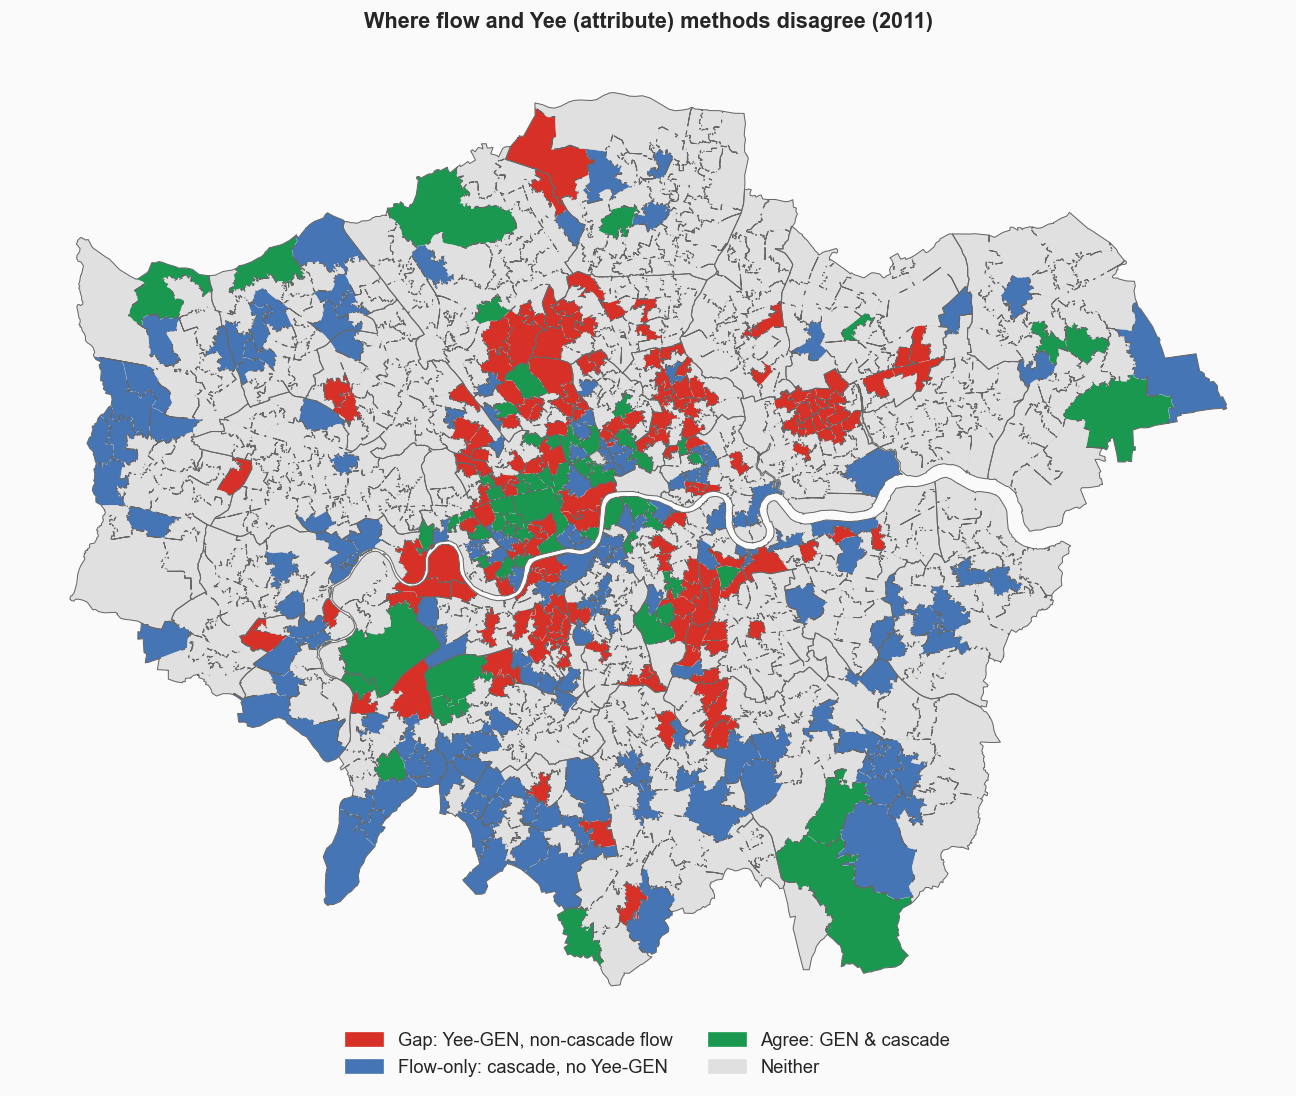

In [27]:
# ── MAP 1 · Yee–flow divergence (the research gap) ─────────────────
gdf = load_london_msoa(GEO_PATH, df)
fig, ax = plt.subplots(figsize=(11, 9))
plot_london_categorical(
    gdf, column='YeeDiv',
    title='Where flow and Yee (attribute) methods disagree (2011)',
    color_dict=YEE_DIV_COLORS, ax=ax)
if ax.get_legend():
    ax.get_legend().remove()
fig.legend(handles=[mpatches.Patch(color=c, label=l) for l, c in YEE_DIV_COLORS.items()],
           loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False, fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_map_yee_divergence_2011.png', bbox_inches='tight')
plt.show()


/Users/xing/Desktop/CASA/dissertation/scripts/map_utils.py:210: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)
/Users/xing/Desktop/CASA/dissertation/scripts/map_utils.py:210: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)


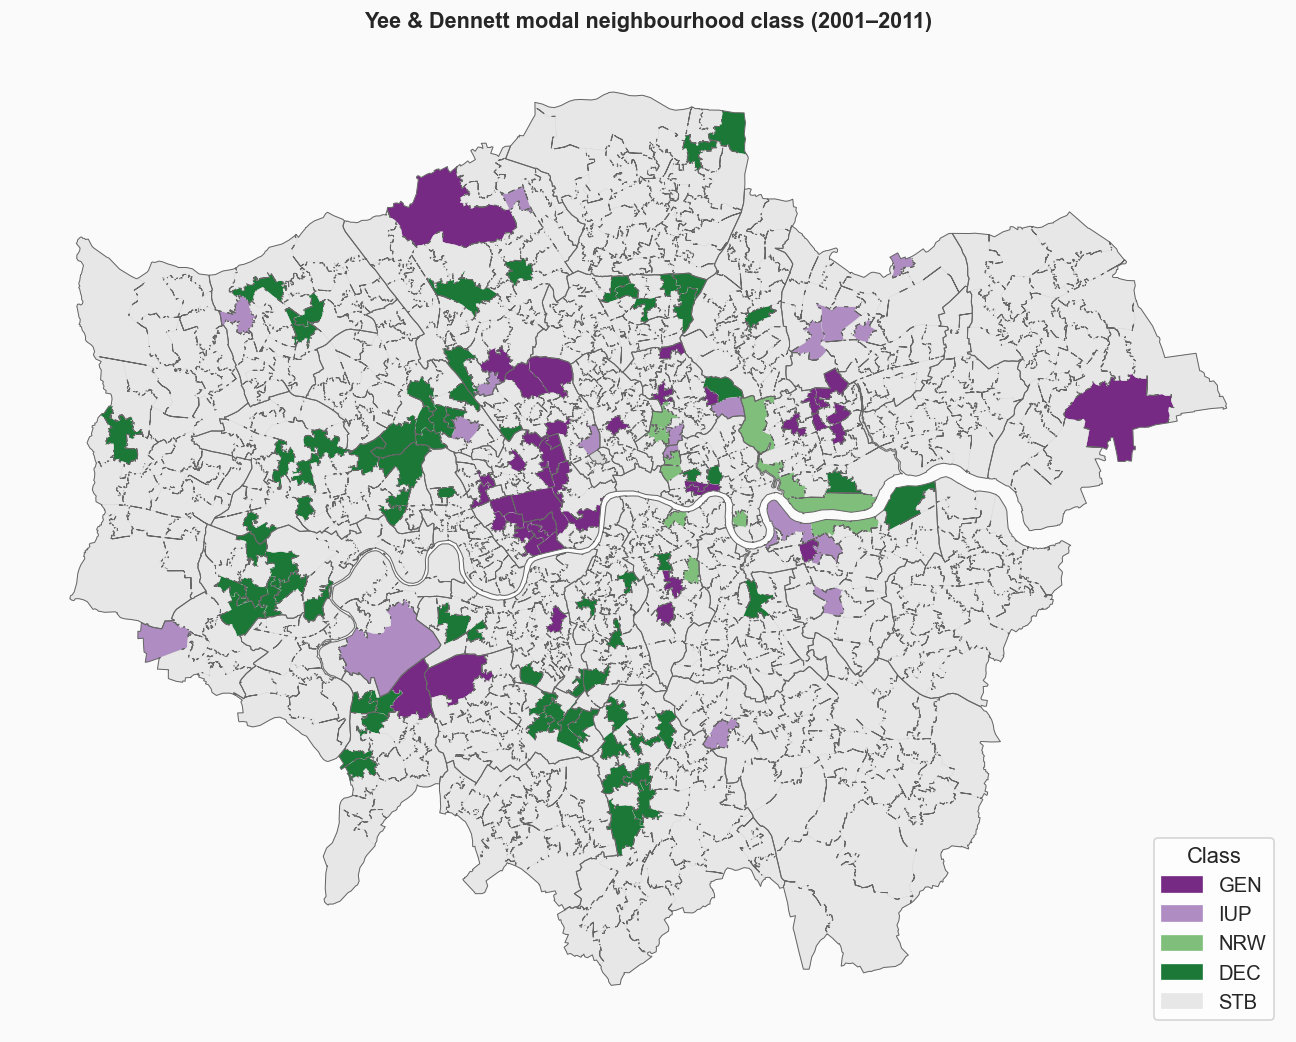

In [28]:
# ── MAP 2 · Yee modal class (attribute typology for reference) ─────
YEE_CLASS_COLORS = {'GEN': '#762a83', 'IUP': '#af8dc3', 'NRW': '#7fbf7b',
                    'DEC': '#1b7837', 'STB': '#e7e7e7'}

gdf = load_london_msoa(GEO_PATH, df.rename(columns={'yee_modal': 'YeeModal'}))
fig, ax = plt.subplots(figsize=(11, 9))

plot_london_categorical(
    gdf, column='YeeModal',
    title='Yee & Dennett modal neighbourhood class (2001–2011)',
    color_dict=YEE_CLASS_COLORS, ax=ax)

# Create custom patches using your color dictionary
legend_handles = [
    mpatches.Patch(color=color, label=label) 
    for label, color in YEE_CLASS_COLORS.items()
]

# Add the legend to the axes
ax.legend(
    handles=legend_handles, 
    title='Class',         # Optional: Add a title to the legend
    loc='lower right',     # Adjust location as needed (e.g., 'upper left', 'best')
    frameon=True           # Set to False if you want no box around the legend
)
# ------------------------

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig02_map_yee_modal_class.png', bbox_inches='tight')
plt.show()


In [29]:
# ── export ─────────────────────────────────────────────────────────
out = OUT_DIR / f'yee_cascade_comparison_20260627.csv'
df.to_csv(out, index=False)
print(f'✓ saved {out}  ({df.shape[0]} x {df.shape[1]})')

✓ saved /Users/xing/Desktop/CASA/dissertation/outputs/yee_cascade_comparison_20260627.csv  (982 x 46)
